1. Outline the steps taken in the EDA process
2. Explain the purpose of each step
3. Explain the conclusions drawn from each step
4. Explain the interpretation of the various statistics generated and how they impact your analysis
5. Generate clear, meaningful, and understandable visualizations that support your findings
6. Organise the notebook so that is it clear and easy to understand

## Exploratory Data Analysis (EDA)

This EDA focuses on insights relevant to:
1. Predicting Temperature (a regression task).
2. Categorising the combined “Plant Type-Stage” (a classification task).
This notebook will identify important patterns, relationships and also potential issues (e.g. missing data, outliers) that will shape the modelling for the ML pipeline later on.

## Retrieve Data from DB

The first step is to import the data from agri.db. We will use the Pandas library to read the data into a DataFrame.

In [1]:
# Copying agri.db to use the relative path `data/calls.db`
import shutil

shutil.copy('data/agri.db', 'data/calls.db')

'data/calls.db'

In [2]:
# Identify the tables in the 'unknown' database
import sqlite3
import pandas as pd

conn = sqlite3.connect('data/calls.db')

cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in the database:", cursor.fetchall())

conn.close()

Tables in the database: [('farm_data',)]


In [3]:
# Display the contents of the 'farm_data' table
from IPython.display import display

conn = sqlite3.connect('data/calls.db')

cursor = conn.cursor()

df = pd.read_sql_query("SELECT * FROM farm_data", conn)

display(df)

conn.close()

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,Herbs,Vine Crops,Maturity,23.34,NaN,454.0,937,1.82,4,161,64,201,6.1,28.150346
1,Zone_G,Herbs,VINE CROPS,Vegetative,-24.16,63.14,441.0,938,2.13,6,161,53,None,6.5,31.000000
2,Zone_F,Herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228,79,292,6.4,26.000000
3,Zone_G,Herbs,fruiting vegetables,Vegetative,22.61,NaN,651.0,1346,1.96,6,None,53 ppm,289,6.6,NaN
4,Zone_B,Vine Crops,LEAFY GREENS,seedling,22.88,NaN,144.0,812,2.76,5,61,19,168,5.5,28.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57484,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57485,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57486,Zone_E,Herbs,VINE CROPS,Seedling,24.85,NaN,203.0,816,0.98,7,121,41,114,4.9,21.000000
57487,Zone_G,Fruiting Vegetables,VINE CROPS,Vegetative,23.45,64.89,502.0,911,2.27,5,190,57,196,5.9,35.000000


## Data Cleaning

The imported data has a lot of unclean data with no standardisation. The next step is to clean the data. This includes handling missing values, converting data types and removing duplicates.

In [4]:
# Fill empty cells with NaN
cols = df.columns
df[cols] = df[cols].fillna('NaN')

display(df)

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,Herbs,Vine Crops,Maturity,23.34,NaN,454.0,937,1.82,4,161,64,201,6.1,28.150346
1,Zone_G,Herbs,VINE CROPS,Vegetative,-24.16,63.14,441.0,938,2.13,6,161,53,NaN,6.5,31.0
2,Zone_F,Herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228,79,292,6.4,26.0
3,Zone_G,Herbs,fruiting vegetables,Vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53 ppm,289,6.6,NaN
4,Zone_B,Vine Crops,LEAFY GREENS,seedling,22.88,NaN,144.0,812,2.76,5,61,19,168,5.5,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57484,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57485,Zone_C,Vine Crops,Fruiting Vegetables,Maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57486,Zone_E,Herbs,VINE CROPS,Seedling,24.85,NaN,203.0,816,0.98,7,121,41,114,4.9,21.0
57487,Zone_G,Fruiting Vegetables,VINE CROPS,Vegetative,23.45,64.89,502.0,911,2.27,5,190,57,196,5.9,35.0


In [5]:
# Convert all object columns to lowercase
object_cols = [
    'Previous Cycle Plant Type',
    'Plant Type',
    'Plant Stage'
]

for col in object_cols:
    df[col] = df[col].str.lower()

display(df)

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,herbs,vine crops,maturity,23.34,NaN,454.0,937,1.82,4,161,64,201,6.1,28.150346
1,Zone_G,herbs,vine crops,vegetative,-24.16,63.14,441.0,938,2.13,6,161,53,NaN,6.5,31.0
2,Zone_F,herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228,79,292,6.4,26.0
3,Zone_G,herbs,fruiting vegetables,vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53 ppm,289,6.6,NaN
4,Zone_B,vine crops,leafy greens,seedling,22.88,NaN,144.0,812,2.76,5,61,19,168,5.5,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57484,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57485,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150,61,210,6.4,NaN
57486,Zone_E,herbs,vine crops,seedling,24.85,NaN,203.0,816,0.98,7,121,41,114,4.9,21.0
57487,Zone_G,fruiting vegetables,vine crops,vegetative,23.45,64.89,502.0,911,2.27,5,190,57,196,5.9,35.0


In [6]:
# Convert numeric columns to fully numeric values
numeric_cols = [
    'Temperature Sensor (°C)',
    'Humidity Sensor (%)',
    'Light Intensity Sensor (lux)',
    'CO2 Sensor (ppm)',
    'EC Sensor (dS/m)',
    'O2 Sensor (ppm)',
    'Nutrient N Sensor (ppm)',
    'Nutrient P Sensor (ppm)',
    'Nutrient K Sensor (ppm)',
    'pH Sensor',
    'Water Level Sensor (mm)'
]

for col in numeric_cols:
    # Ensure the column is a string first
    df[col] = df[col].astype(str)
    
    # Remove any characters like units and aren't digits, a decimal point or a minus sign
    df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
    
    # Convert the clean string to a numeric type and errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ensure 'Water Level Sensor (mm)' is 2 decimal places
df['Water Level Sensor (mm)'] = df['Water Level Sensor (mm)'].round(2)

display(df)


,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,herbs,vine crops,maturity,23.34,NaN,454.0,937,1.82,4,161.0,64.0,201.0,6.1,28.15
1,Zone_G,herbs,vine crops,vegetative,-24.16,63.14,441.0,938,2.13,6,161.0,53.0,NaN,6.5,31.00
2,Zone_F,herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228.0,79.0,292.0,6.4,26.00
3,Zone_G,herbs,fruiting vegetables,vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53.0,289.0,6.6,NaN
4,Zone_B,vine crops,leafy greens,seedling,22.88,NaN,144.0,812,2.76,5,61.0,19.0,168.0,5.5,28.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57484,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150.0,61.0,210.0,6.4,NaN
57485,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150.0,61.0,210.0,6.4,NaN
57486,Zone_E,herbs,vine crops,seedling,24.85,NaN,203.0,816,0.98,7,121.0,41.0,114.0,4.9,21.00
57487,Zone_G,fruiting vegetables,vine crops,vegetative,23.45,64.89,502.0,911,2.27,5,190.0,57.0,196.0,5.9,35.00


In [7]:
# Remove duplicates
df = df.drop_duplicates()

display(df)

,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,herbs,vine crops,maturity,23.34,NaN,454.0,937,1.82,4,161.0,64.0,201.0,6.1,28.15
1,Zone_G,herbs,vine crops,vegetative,-24.16,63.14,441.0,938,2.13,6,161.0,53.0,NaN,6.5,31.00
2,Zone_F,herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228.0,79.0,292.0,6.4,26.00
3,Zone_G,herbs,fruiting vegetables,vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53.0,289.0,6.6,NaN
4,Zone_B,vine crops,leafy greens,seedling,22.88,NaN,144.0,812,2.76,5,61.0,19.0,168.0,5.5,28.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57483,Zone_G,herbs,herbs,seedling,25.79,NaN,262.0,1115,1.36,6,147.0,34.0,186.0,6.3,27.00
57484,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150.0,61.0,210.0,6.4,NaN
57486,Zone_E,herbs,vine crops,seedling,24.85,NaN,203.0,816,0.98,7,121.0,41.0,114.0,4.9,21.00
57487,Zone_G,fruiting vegetables,vine crops,vegetative,23.45,64.89,502.0,911,2.27,5,190.0,57.0,196.0,5.9,35.00


## Data Pre-processing

After cleaning the data, we will pre-process the data to make the data logical and easier to work with.

In [8]:
# Rename vague columns for clearer standardised naming
df = df.rename(columns={
    'Previous Cycle Plant Type': 'Previous Plant Type',
    'Plant Type': 'Current Plant Type',
    'Temperature Sensor (°C)': 'Temperature (°C)',
    'Humidity Sensor (%)': 'Humidity (%)',
    'Light Intensity Sensor (lux)': 'Light Intensity (lux)',
    'CO2 Sensor (ppm)': 'CO2 (ppm)',
    'EC Sensor (dS/m)': 'EC (dS/m)',
    'O2 Sensor (ppm)': 'O2 (ppm)',
    'Nutrient N Sensor (ppm)': 'Nitrogen (ppm)',
    'Nutrient P Sensor (ppm)': 'Phosphorus (ppm)',
    'Nutrient K Sensor (ppm)': 'Potassium (ppm)',
    'pH Sensor': 'pH',
    'Water Level Sensor (mm)': 'Water Level (mm)'
})

display(df)

,System Location Code,Previous Plant Type,Current Plant Type,Plant Stage,Temperature (°C),Humidity (%),Light Intensity (lux),CO2 (ppm),EC (dS/m),O2 (ppm),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),pH,Water Level (mm)
0,Zone_D,herbs,vine crops,maturity,23.34,NaN,454.0,937,1.82,4,161.0,64.0,201.0,6.1,28.15
1,Zone_G,herbs,vine crops,vegetative,-24.16,63.14,441.0,938,2.13,6,161.0,53.0,NaN,6.5,31.00
2,Zone_F,herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228.0,79.0,292.0,6.4,26.00
3,Zone_G,herbs,fruiting vegetables,vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53.0,289.0,6.6,NaN
4,Zone_B,vine crops,leafy greens,seedling,22.88,NaN,144.0,812,2.76,5,61.0,19.0,168.0,5.5,28.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57483,Zone_G,herbs,herbs,seedling,25.79,NaN,262.0,1115,1.36,6,147.0,34.0,186.0,6.3,27.00
57484,Zone_C,vine crops,fruiting vegetables,maturity,NaN,NaN,619.0,1074,1.95,6,150.0,61.0,210.0,6.4,NaN
57486,Zone_E,herbs,vine crops,seedling,24.85,NaN,203.0,816,0.98,7,121.0,41.0,114.0,4.9,21.00
57487,Zone_G,fruiting vegetables,vine crops,vegetative,23.45,64.89,502.0,911,2.27,5,190.0,57.0,196.0,5.9,35.00


In [9]:
# Reindex columns based on logical order
new_order = [
    # Essential Plant Information
    'System Location Code',
    'Current Plant Type',

    # Additional Plant Information
    'Plant Stage',
    'Previous Plant Type',
    
    # Environmental Conditions
    'Temperature (°C)',
    'Humidity (%)',
    'Light Intensity (lux)',
    'CO2 (ppm)',
    'O2 (ppm)',
    'EC (dS/m)',
    
    # Nutrient Measurements
    'Nitrogen (ppm)',
    'Phosphorus (ppm)',
    'Potassium (ppm)',
    
    # Water Measurement
    'Water Level (mm)',
    'pH'
]

df = df.reindex(columns=new_order)

display(df)

,System Location Code,Current Plant Type,Plant Stage,Previous Plant Type,Temperature (°C),Humidity (%),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
0,Zone_D,vine crops,maturity,herbs,23.34,NaN,454.0,937,4,1.82,161.0,64.0,201.0,28.15,6.1
1,Zone_G,vine crops,vegetative,herbs,-24.16,63.14,441.0,938,6,2.13,161.0,53.0,NaN,31.00,6.5
2,Zone_F,herbs,maturity,herbs,23.84,NaN,562.0,1246,8,1.21,228.0,79.0,292.0,26.00,6.4
3,Zone_G,fruiting vegetables,vegetative,herbs,22.61,NaN,651.0,1346,6,1.96,NaN,53.0,289.0,NaN,6.6
4,Zone_B,leafy greens,seedling,vine crops,22.88,NaN,144.0,812,5,2.76,61.0,19.0,168.0,28.00,5.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57483,Zone_G,herbs,seedling,herbs,25.79,NaN,262.0,1115,6,1.36,147.0,34.0,186.0,27.00,6.3
57484,Zone_C,fruiting vegetables,maturity,vine crops,NaN,NaN,619.0,1074,6,1.95,150.0,61.0,210.0,NaN,6.4
57486,Zone_E,vine crops,seedling,herbs,24.85,NaN,203.0,816,7,0.98,121.0,41.0,114.0,21.00,4.9
57487,Zone_G,vine crops,vegetative,fruiting vegetables,23.45,64.89,502.0,911,5,2.27,190.0,57.0,196.0,35.00,5.9


In [10]:
# Sort rows to see data relationships
df = df.sort_values(by=['System Location Code', 'Current Plant Type', 'Plant Stage', 'Previous Plant Type']).reset_index(drop=True)

display(df)

,System Location Code,Current Plant Type,Plant Stage,Previous Plant Type,Temperature (°C),Humidity (%),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
0,Zone_A,fruiting vegetables,maturity,fruiting vegetables,27.14,NaN,622.0,1406,9,1.84,174.0,NaN,292.0,30.80,6.4
1,Zone_A,fruiting vegetables,maturity,fruiting vegetables,26.07,64.68,738.0,1086,8,1.86,NaN,55.0,236.0,13.75,6.5
2,Zone_A,fruiting vegetables,maturity,fruiting vegetables,24.63,NaN,628.0,1286,6,2.40,177.0,66.0,200.0,30.65,6.3
3,Zone_A,fruiting vegetables,maturity,fruiting vegetables,22.74,NaN,699.0,1429,7,1.60,200.0,68.0,225.0,10.64,6.1
4,Zone_A,fruiting vegetables,maturity,fruiting vegetables,22.94,NaN,643.0,1097,9,1.54,190.0,NaN,200.0,36.53,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Zone_G,vine crops,vegetative,vine crops,NaN,NaN,500.0,932,7,1.89,174.0,55.0,186.0,29.00,5.8
49996,Zone_G,vine crops,vegetative,vine crops,NaN,NaN,593.0,889,6,1.18,184.0,65.0,241.0,20.00,5.5
49997,Zone_G,vine crops,vegetative,vine crops,NaN,NaN,574.0,931,7,1.26,185.0,NaN,232.0,34.43,5.9
49998,Zone_G,vine crops,vegetative,vine crops,25.62,64.59,419.0,892,5,1.12,173.0,58.0,250.0,29.00,5.4


## Data Visualisation

Now we can visualize the data to gain insights on our relevant task.

### Initial Data Inspection

In [23]:
# Preview the Dataset Structure
## 1. Check the shape of dataset (rows, columns)
print("DataFrame shape:", df.shape)

print("-" * 50)

## 2. View data types and other info
print("DataFrame info:")
df.info()

print("-" * 50)

## 3. View number of NaN values in each column
print("NaN values per column:")
print(df.isna().sum())


DataFrame shape: (50000, 15)
--------------------------------------------------
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   System Location Code   50000 non-null  object 
 1   Current Plant Type     50000 non-null  object 
 2   Plant Stage            50000 non-null  object 
 3   Previous Plant Type    50000 non-null  object 
 4   Temperature (°C)       42416 non-null  float64
 5   Humidity (%)           16214 non-null  float64
 6   Light Intensity (lux)  46276 non-null  float64
 7   CO2 (ppm)              50000 non-null  int64  
 8   O2 (ppm)               50000 non-null  int64  
 9   EC (dS/m)              50000 non-null  float64
 10  Nitrogen (ppm)         41328 non-null  float64
 11  Phosphorus (ppm)       45042 non-null  float64
 12  Potassium (ppm)        46781 non-null  float64
 13  Water Leve

In [56]:
# High-Level Summaries
## 1. Statistics for Numeric Columns
print("Statistics for Numeric Columns:")
print("Editor's Note: No obvious outliers in the data based on min, max and std.")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
display(df[numeric_cols].describe())

print("-" * 50)

## 2. Statistics for Categorical Columns
print("Statistics for Categorical Columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
display(df[categorical_cols].describe())
for col in categorical_cols:
    print("Column:")
    print(df[col].value_counts())
    print("Unique Values:", df[col].unique())
    print("-" * 3)

Statistics for Numeric Columns:
Editor's Note: No obvious outliers in the data based on min, max and std.


,Temperature (°C),Humidity (%),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
count,42416.000000,16214.000000,46276.000000,50000.000000,50000.00000,50000.000000,41328.000000,45042.000000,46781.000000,42486.000000,50000.000000
mean,22.161807,69.230421,398.339485,1083.223440,6.58100,1.624247,157.768849,49.865526,218.062696,25.723973,6.021598
std,7.483871,5.728011,222.320399,172.529164,1.14746,0.415122,45.632916,15.416017,60.723034,5.823993,0.400561
min,-28.570000,59.220000,-799.000000,799.000000,3.00000,-0.250000,49.000000,19.000000,99.000000,10.000000,3.800000
25%,22.140000,64.340000,257.000000,950.000000,6.00000,1.360000,124.000000,37.000000,170.000000,21.330000,5.800000
50%,23.210000,68.660000,404.000000,1071.000000,7.00000,1.650000,158.000000,50.000000,215.000000,26.000000,6.000000
75%,24.350000,74.100000,553.000000,1178.000000,7.00000,1.900000,190.000000,62.000000,266.000000,30.000000,6.300000
max,28.750000,81.140000,800.000000,1500.000000,11.00000,3.440000,250.000000,80.000000,350.000000,40.000000,7.800000


--------------------------------------------------
Statistics for Categorical Columns:


,System Location Code,Current Plant Type,Plant Stage,Previous Plant Type
count,50000,50000,50000,50000
unique,7,4,3,4
top,Zone_C,fruiting vegetables,seedling,fruiting vegetables
freq,7218,12559,16854,12592


Column:
System Location Code
Zone_C    7218
Zone_G    7206
Zone_E    7204
Zone_B    7200
Zone_A    7075
Zone_F    7071
Zone_D    7026
Name: count, dtype: int64
Unique Values: ['Zone_A' 'Zone_B' 'Zone_C' 'Zone_D' 'Zone_E' 'Zone_F' 'Zone_G']
---
Column:
Current Plant Type
fruiting vegetables    12559
herbs                  12528
leafy greens           12502
vine crops             12411
Name: count, dtype: int64
Unique Values: ['fruiting vegetables' 'herbs' 'leafy greens' 'vine crops']
---
Column:
Plant Stage
seedling      16854
vegetative    16608
maturity      16538
Name: count, dtype: int64
Unique Values: ['maturity' 'seedling' 'vegetative']
---
Column:
Previous Plant Type
fruiting vegetables    12592
leafy greens           12568
vine crops             12459
herbs                  12381
Name: count, dtype: int64
Unique Values: ['fruiting vegetables' 'herbs' 'leafy greens' 'vine crops']
---


### Univariate Analysis

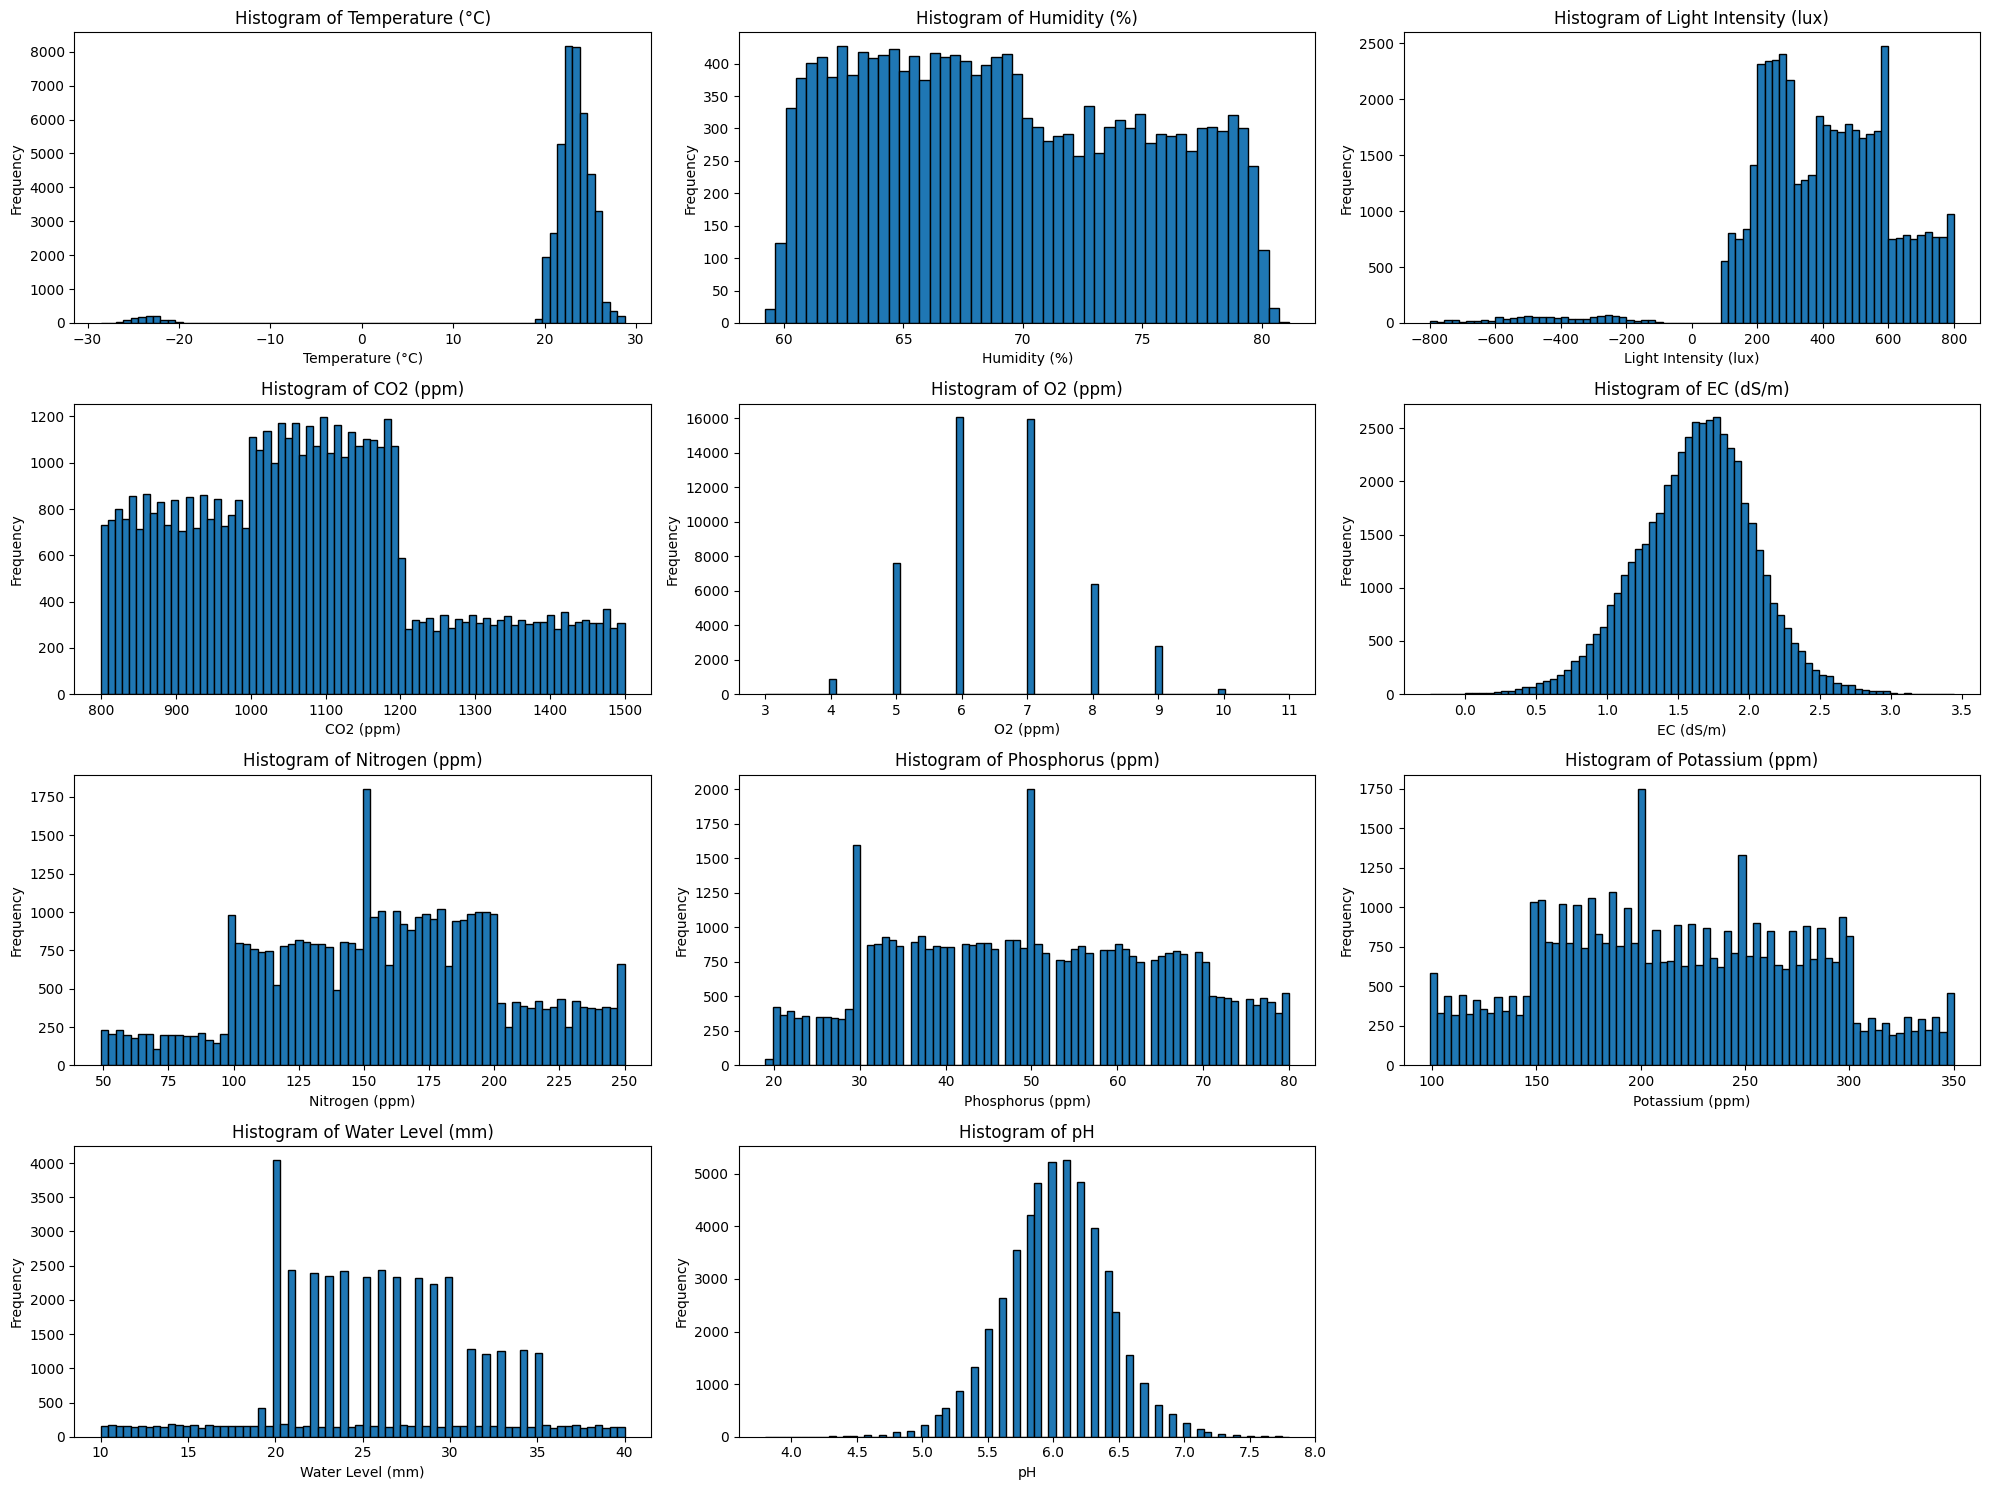

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot Histograms for numeric features to inspect their distributions
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1)
    
    ## We will choose the best number of bins using Rice criterion to produce a good distribution in the histogram.
    ### Use total number of non-null points for Rice criterion
    n_points = len(df[col].dropna())
    ### Apply the Rice criterion: number of bins = ceil(2 * n^(1/3))
    bins = int(np.ceil(2 * (n_points ** (1/3))))

    plt.hist(df[col].dropna(), bins=bins, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# # 2. Plot Box Plots to check for outliers in numeric features
# for col in numeric_cols:
#     plt.figure(figsize=(8, 4))
#     plt.boxplot(df[col].dropna(), vert=False)
#     plt.title(f'Box Plot of {col}')
#     plt.xlabel(col)
#     plt.show()

# # 3. Bar Plots for each categorical column to view frequency distributions
# for col in categorical_cols:
#     plt.figure(figsize=(10, 4))
#     df[col].value_counts().plot(kind='bar')
#     plt.title(f'Bar Plot of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Count')
#     plt.show()

### Statistics for predicting the temperature conditions

#### Humidity (%) vs Temperature (°C)

#### Light Intensity (lux) vs Temperature (°C)

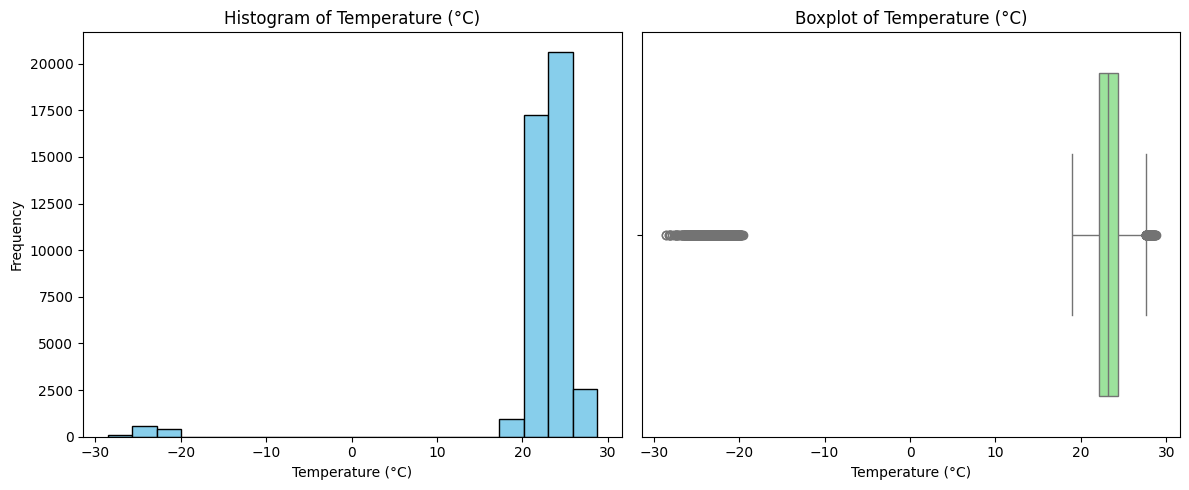

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots: Histogram and Boxplot for Temperature
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Temperature (°C)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

# Boxplot using seaborn for better aesthetics
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Temperature (°C)'], color='lightgreen')
plt.title('Boxplot of Temperature (°C)')

plt.tight_layout()
plt.show()


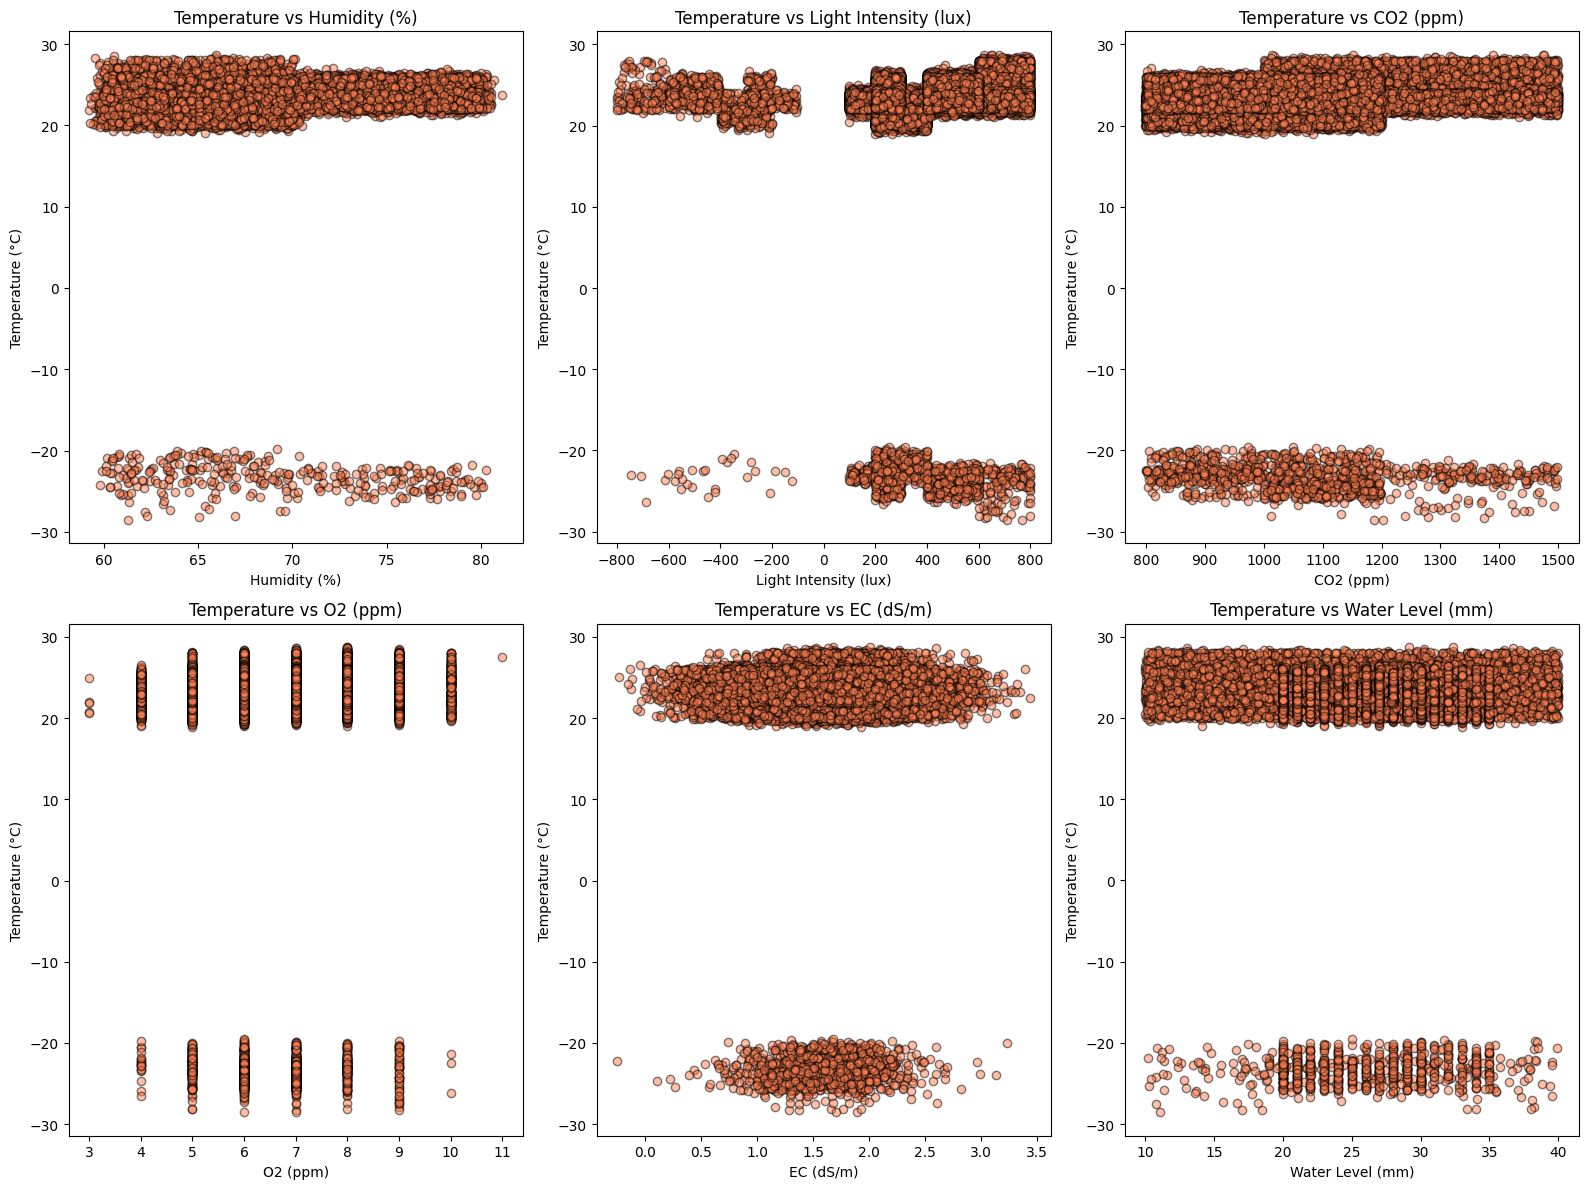

In [16]:
# List of sensor columns to compare with temperature
sensors = ['Humidity (%)', 'Light Intensity (lux)', 'CO2 (ppm)', 'O2 (ppm)', 'EC (dS/m)', 'Water Level (mm)']

plt.figure(figsize=(16, 12))

# Loop through the sensor list and create a subplot for each sensor vs Temperature
for i, sensor in enumerate(sensors):
    plt.subplot(2, 3, i+1)
    plt.scatter(df[sensor], df['Temperature (°C)'], alpha=0.5, color='coral', edgecolor='black')
    plt.xlabel(sensor)
    plt.ylabel('Temperature (°C)')
    plt.title(f'Temperature vs {sensor}')

plt.tight_layout()
plt.show()


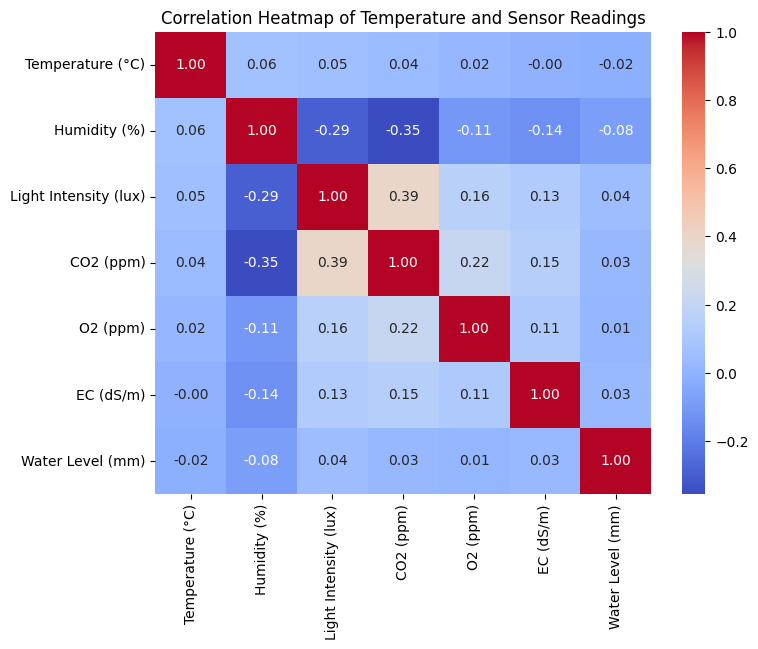

In [17]:
# Define the relevant columns for temperature prediction
relevant_columns = [
    'Temperature (°C)', 
    'Humidity (%)', 
    'Light Intensity (lux)', 
    'CO2 (ppm)', 
    'O2 (ppm)', 
    'EC (dS/m)', 
    'Water Level (mm)'
]

# Compute the correlation matrix
corr_matrix = df[relevant_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Temperature and Sensor Readings')
plt.show()


c:\Users\tanhu\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


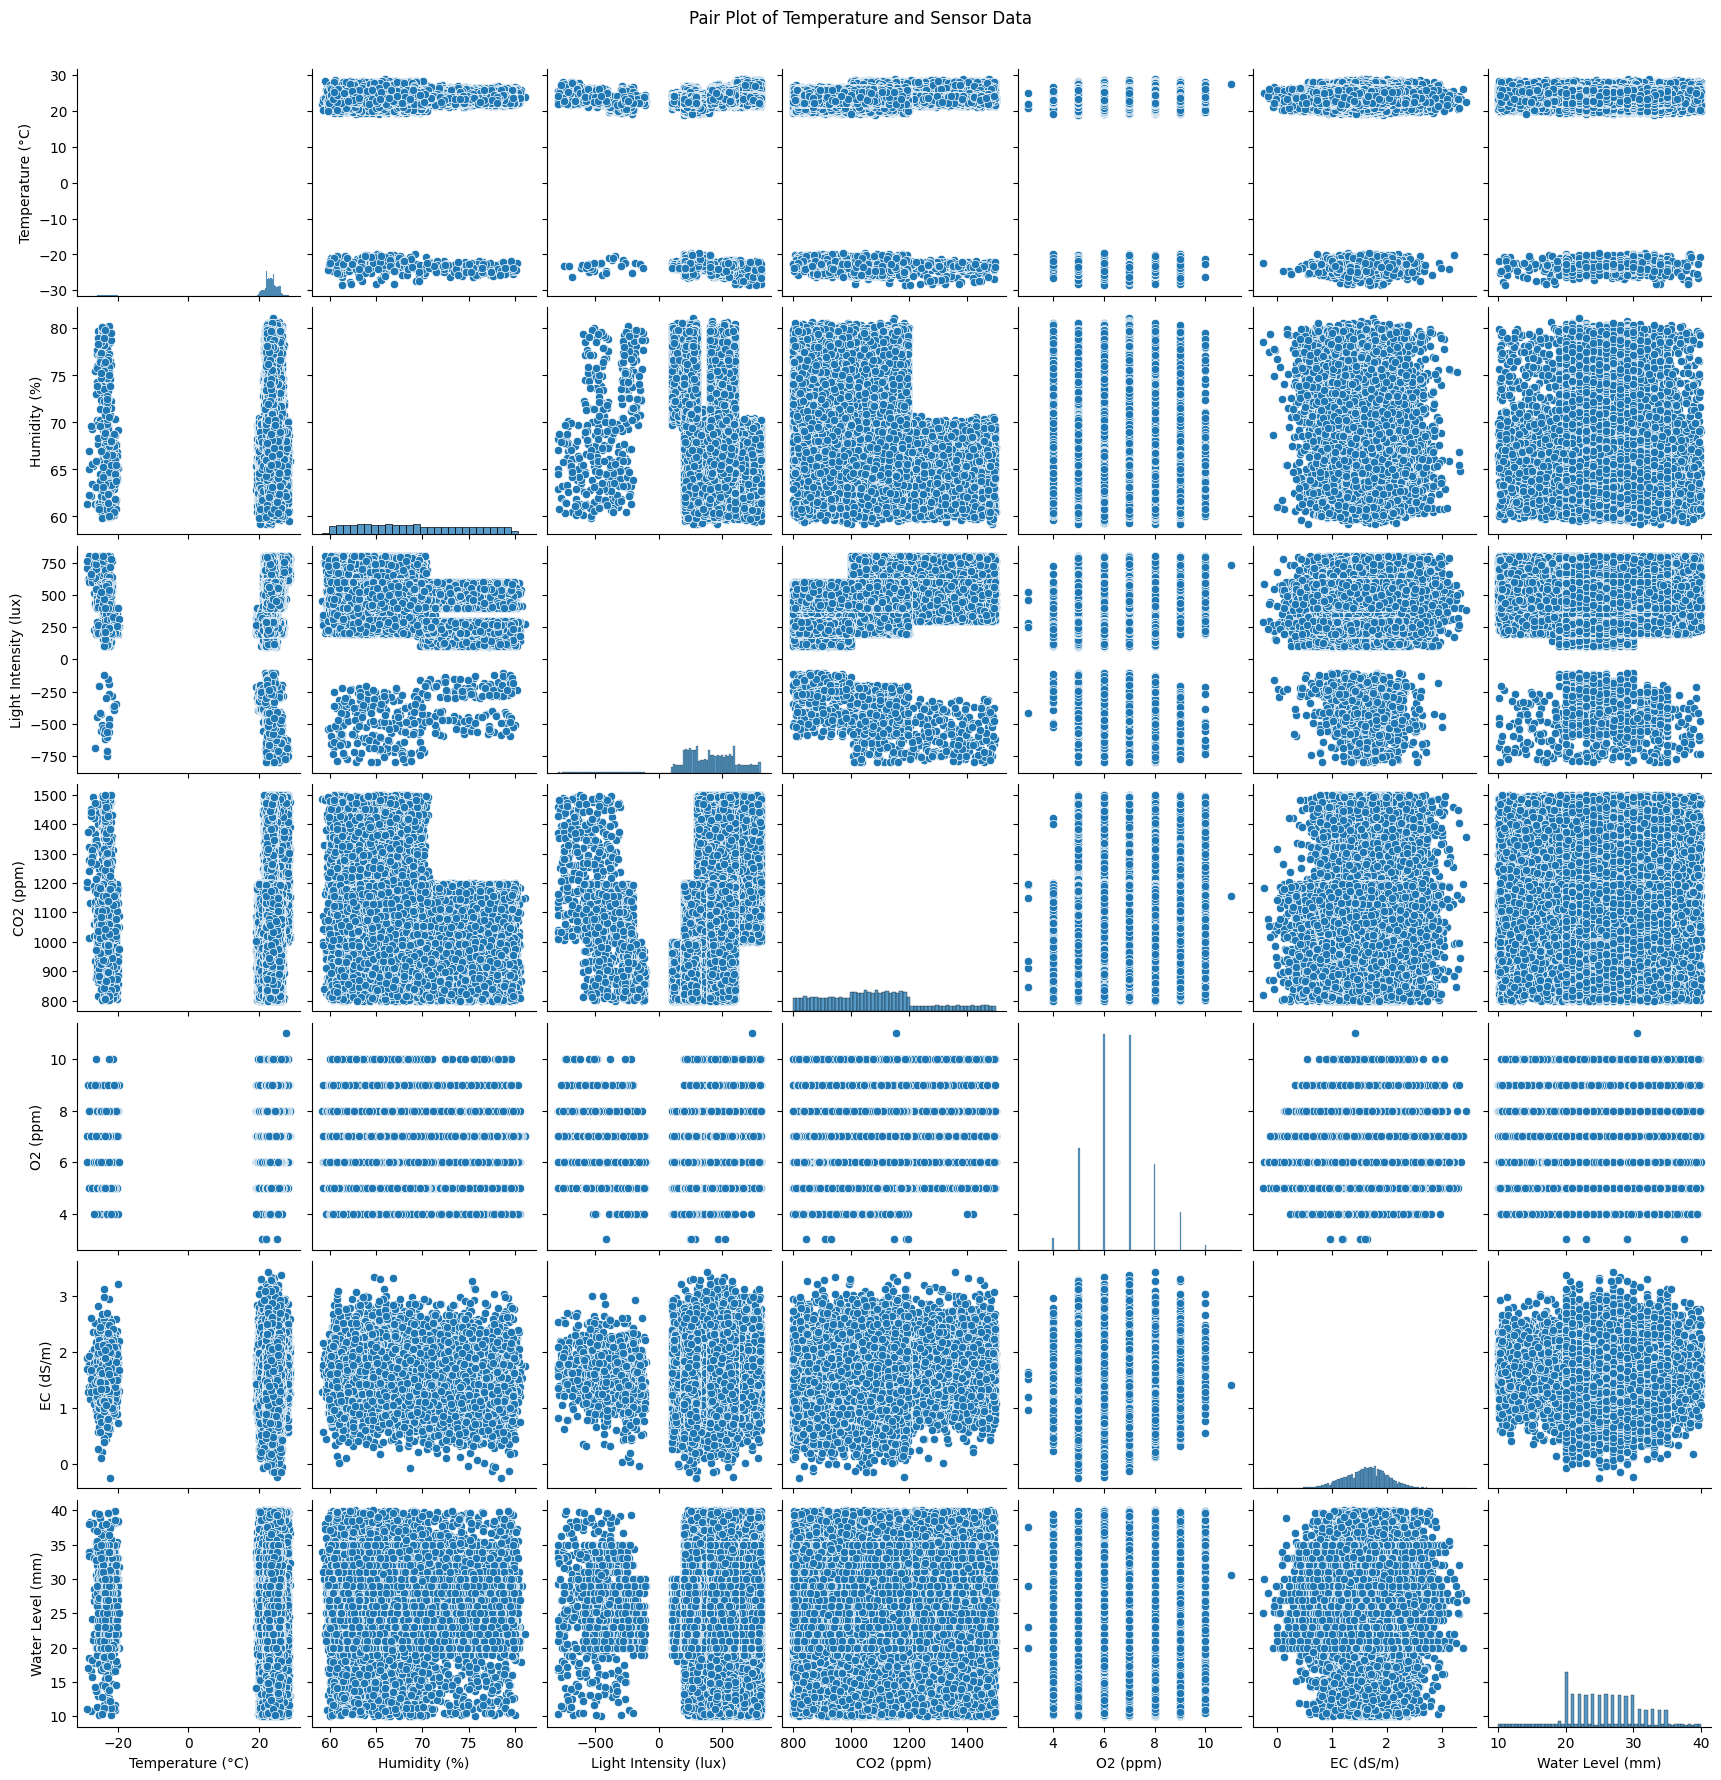

In [18]:
sns.pairplot(df[relevant_columns])
plt.suptitle("Pair Plot of Temperature and Sensor Data", y=1.02)
plt.show()


In [19]:
df.describe()

,Temperature (°C),Humidity (%),Light Intensity (lux),CO2 (ppm),O2 (ppm),EC (dS/m),Nitrogen (ppm),Phosphorus (ppm),Potassium (ppm),Water Level (mm),pH
count,42416.000000,16214.000000,46276.000000,50000.000000,50000.00000,50000.000000,41328.000000,45042.000000,46781.000000,42486.000000,50000.000000
mean,22.161807,69.230421,398.339485,1083.223440,6.58100,1.624247,157.768849,49.865526,218.062696,25.723973,6.021598
std,7.483871,5.728011,222.320399,172.529164,1.14746,0.415122,45.632916,15.416017,60.723034,5.823993,0.400561
min,-28.570000,59.220000,-799.000000,799.000000,3.00000,-0.250000,49.000000,19.000000,99.000000,10.000000,3.800000
25%,22.140000,64.340000,257.000000,950.000000,6.00000,1.360000,124.000000,37.000000,170.000000,21.330000,5.800000
50%,23.210000,68.660000,404.000000,1071.000000,7.00000,1.650000,158.000000,50.000000,215.000000,26.000000,6.000000
75%,24.350000,74.100000,553.000000,1178.000000,7.00000,1.900000,190.000000,62.000000,266.000000,30.000000,6.300000
max,28.750000,81.140000,800.000000,1500.000000,11.00000,3.440000,250.000000,80.000000,350.000000,40.000000,7.800000


### Statistics about combined "Plant Type-Stage" based on sensor data

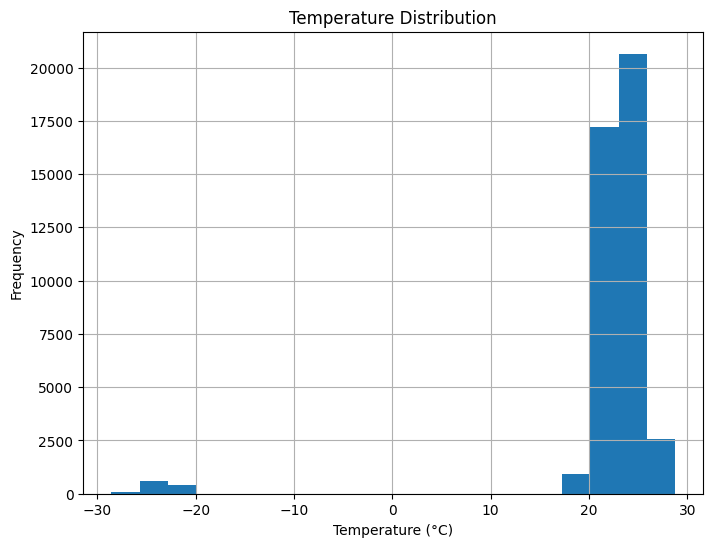

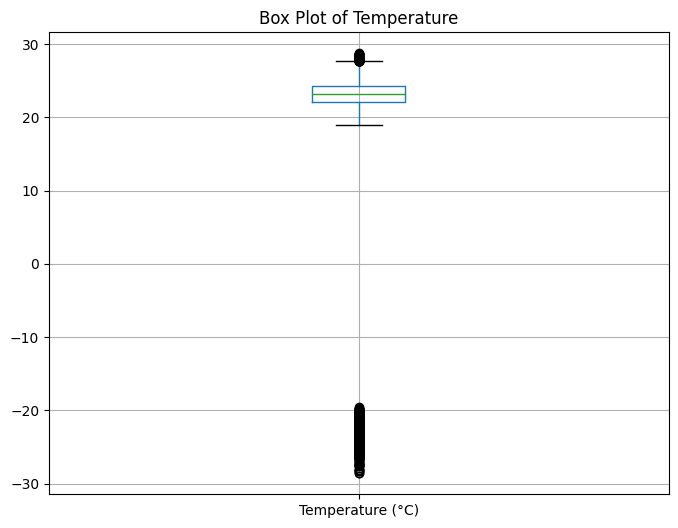

In [20]:
import matplotlib.pyplot as plt

# Histogram for Temperature
df['Temperature (°C)'].hist(bins=20, figsize=(8,6))
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# Box Plot for Temperature
df.boxplot(column='Temperature (°C)', figsize=(8,6))
plt.title("Box Plot of Temperature")
plt.show()

In [21]:
import seaborn as sns

plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Zone_A'

<Figure size 1000x800 with 0 Axes>